### Regression Problem

In [173]:
import pandas as pd
import numpy as np

**Data Preparation**

In [174]:
raw_data = pd.read_csv("../Datasets/data.csv")
df = raw_data.copy()

In [175]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [176]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [177]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [178]:
strings = list(df.dtypes[df.dtypes == "str"].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [179]:
for col in strings:
    df[col]= df[col].str.lower().str.replace(" ","_")

In [180]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


**Exploratory data analysis**

In [181]:
for col in df.columns:
    print(col)
    print("Unique values: ",df[col].unique()[:5])
    print("no of Unique :", df[col].nunique())
    print("_"*50)

make
Unique values:  <StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
no of Unique : 48
__________________________________________________
model
Unique values:  <StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
no of Unique : 914
__________________________________________________
year
Unique values:  [2011 2012 2013 1992 1993]
no of Unique : 28
__________________________________________________
engine_fuel_type
Unique values:  <StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
no of Unique : 10
__________________________________________________
engine_hp
Unique values:  [335. 300. 230. 320. 172.]
no of Unique : 356
__________________________________________________
engine_cylinders
Unique values:  [ 6.  4.  5.  8. 12.]
no of Unique : 9
_________

**Distribution of price**

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

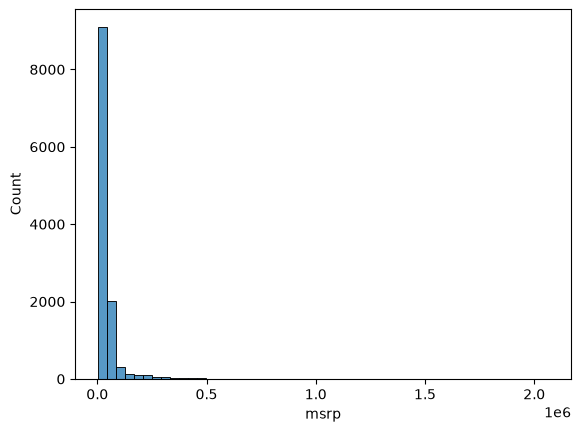

In [183]:
sns.histplot(df.msrp, bins=50);

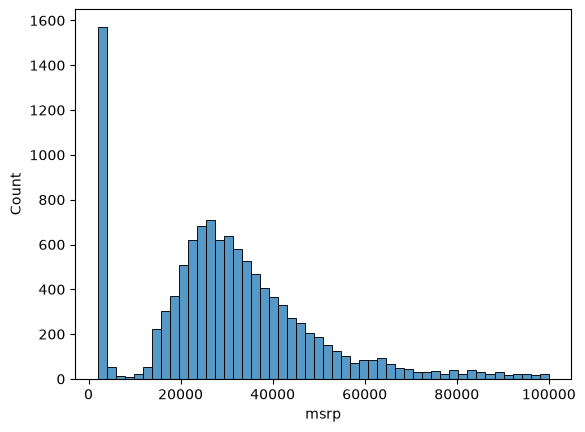

In [184]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50);

In [185]:
np.log([1,10,1000,10000])

array([0.        , 2.30258509, 6.90775528, 9.21034037])

In [186]:
np.log1p([0,1,10,1000,10000])

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [187]:
price_logs = np.log1p(df.msrp)

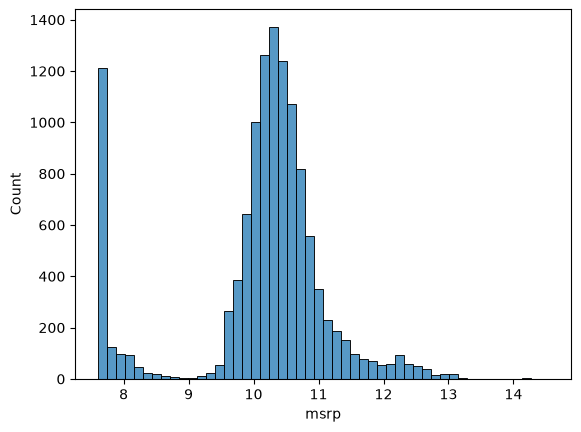

In [188]:
sns.histplot(price_logs, bins=50);

**Setting up the Validation Framework**

we will divide our data into train test val
- train = 60%
- val = 20%
- test = 20%

In [189]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [190]:
n_val , n_test , n_train

(2382, 2382, 7150)

In [191]:
idx = np.arange(n)

In [192]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [193]:
np.random.seed(2)
np.random.shuffle(idx)

In [194]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [195]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_val + n_train:]]

In [196]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [197]:
len(df_train) ,len(df_test), len(df_val)

(7150, 2382, 2382)

In [198]:
df_train= df_train.reset_index(drop=True)
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

In [199]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [200]:
del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]

In [201]:
len(y_train)

7150

**Linear Regression**

In [202]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

**Linear regression model:**

$$
\begin{aligned}
g(x_i) &= w_0 + w_1(x_1) + w_2(x_2) + w_3(x_3) \\
       &= w_0 + \sum_{j=1}^{3} w_jx_j
\end{aligned}
$$

where:

$$
x_1 = 453,\quad x_2 = 11,\quad x_3 = 86
$$

Therefore:

$$
\begin{aligned}
g(x_i) &= w_0 + w_1(453) + w_2(11) + w_3(86) \\
       &= 7.17 + 0.01(453) + 0.04(11) + 0.002(86)\\
       &= 12.312
\end{aligned}
$$

In [203]:
xi = [453, 11, 86]

In [204]:
w0 = 7.17
w = [0.01,0.04,0.002]

In [205]:
def Linear_regression(xi):
    pred = w0
    for i in range(len(xi)):
        pred +=  w[i] *xi[i]
    return pred

In [206]:
Linear_regression(xi)

12.312

In [207]:
# undo logorithm
np.expm1(12.312) 

np.float64(222347.2221101062)

In [208]:
np.log1p(222347.2221101062)

np.float64(12.312)

**Linear regression Vector form**

In [209]:
def dot(xi,w):
    res =0
    for j in range(len(xi)):
        res += xi[j] * w[j]
    return res

In [210]:
def Linear_regression(xi):
    return w0 + dot(xi,w)

If you have **n features**, the weight vector can be represented as:

$$
w =
\begin{bmatrix}
w_0 & w_1 & w_2 & \cdots & w_n
\end{bmatrix}
$$

For one data point:

$$
x_i =
\begin{bmatrix}
1 & x_{i1} & x_{i2} & \cdots & x_{in}
\end{bmatrix}
$$

The `1` is included to account for the intercept $w_0$.

Therefore:

$$
g(x_i) = wx_i^T
$$

which gives:

$$
g(x_i)
=
w_0(1) + w_1x_{i1} + w_2x_{i2} + \cdots + w_nx_{in}
$$

or equivalently:

$$
g(x_i) = \sum_{j=0}^{n} w_jx_{ij}
$$

where $x_{i0}=1$.


In [211]:
w_new = [w0] + w

In [212]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [213]:
def Linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [214]:
Linear_regression(xi)

12.312

**Linear Regression: Matrix Form:**

$$
\underbrace{
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1n}\\
1 & x_{21} & \cdots & x_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
1 & x_{m1} & \cdots & x_{mn}
\end{bmatrix}
}_{X}
\underbrace{
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
}_{w}
=
\underbrace{
\begin{bmatrix}
x_1^T w\\
x_2^T w\\
\vdots\\
x_m^T w
\end{bmatrix}
}_{\text{predictions}}
=
\underbrace{
\begin{bmatrix}
\hat{y}_1\\
\hat{y}_2\\
\vdots\\
\hat{y}_m
\end{bmatrix}
}_{\text{predictions}}
$$

$$
\boxed{\hat{y} = Xw}
$$

In [215]:
xi = [453,11,86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [216]:
x1 = [1,148,24,1385]
x2 = [1,132,25,2031]
x10 = [1,453,11,86]

X =[x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [217]:
def Linear_regression(X):
    return X.dot(w_new)

In [218]:
Linear_regression(X)

array([12.38 , 13.552, 12.312])